<a href="https://colab.research.google.com/github/ekuffuor/cms-dialysis-analysis/blob/main/cms_dialysis_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMS Dialysis Facility Analysis
**Author:** Emmanuel Osei Kuffuor  
**Data source:** CMS Dialysis Facility Compare (public dataset)  
**Goal:** Analyze dialysis facility quality metrics across the United States
to identify patterns in patient outcomes, facility performance, and
regional disparities.  
**Last Updated:** 06/13/2026

In [ ]:
# Import the data manipulation library
import pandas as pd

# Import the visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual theme for seaborn
sns.set_theme(style="whitegrid")

# Show all columns when we print the dataframe
pd.set_option('display.max_columns', None)

## Data Loading & Initial Exploration

In [ ]:
url = "https://data.cms.gov/sites/default/files/2024-02/b2c2658d-e19d-48db-8b3b-9d343a4d395f/dfr_facility_socrata_fy2024.csv"

# latin-1 encoding handles special characters in older government
# datasets that UTF-8 cannot decode
# low_memory=False forces pandas to read the entire file before
# inferring column data types, preventing mixed-type warnings
# caused by chunk-by-chunk type inference on large files

# Read the CSV into a dataframe called df
df = pd.read_csv(url, encoding='latin-1', low_memory=False)

# Print the number of rows and columns
print(f"Dataset shape: {df.shape}")

# Show the first 5 rows
df.head(5)

Dataset shape: (11679242, 14)


,state,CCN,Provider_Name,city,Ownership_Type,ESRD_Network,NPI,Chain,Modality,Alternate_CCNs,Measure,Measure_Score,year,Measure_ID
0,AL,12306,CHILDRENS HOSPITAL OF ALABAMA ESRD,BIRMINGHAM,Unavailable,8,1720166085,INDEPENDENT,Hemodialysis and Peritoneal Dialysis,"012306,013300",F: COVID - Number of Medicare dialysis patient...,11.00,"Quarter 2, 2022",allmcpatq2_f
1,AL,12306,CHILDRENS HOSPITAL OF ALABAMA ESRD,BIRMINGHAM,Unavailable,8,1720166085,INDEPENDENT,Hemodialysis and Peritoneal Dialysis,"012306,013300",F: COVID - Number of patients initially infect...,0.00,"Quarter 2, 2022",allmcFcovpatq2_f
2,AL,12306,CHILDRENS HOSPITAL OF ALABAMA ESRD,BIRMINGHAM,Unavailable,8,1720166085,INDEPENDENT,Hemodialysis and Peritoneal Dialysis,"012306,013300",F: COVID - % of Medicare patients initially in...,0.00,"Quarter 2, 2022",allmcFcovpatPq2_f
3,AL,12306,CHILDRENS HOSPITAL OF ALABAMA ESRD,BIRMINGHAM,Unavailable,8,1720166085,INDEPENDENT,Hemodialysis and Peritoneal Dialysis,"012306,013300",F: COVID - Number of patients ever infected wi...,1.00,"Quarter 2, 2022",allmcEcovpatq2_f
4,AL,12306,CHILDRENS HOSPITAL OF ALABAMA ESRD,BIRMINGHAM,Unavailable,8,1720166085,INDEPENDENT,Hemodialysis and Peritoneal Dialysis,"012306,013300",F: COVID - % of Medicare patients ever infecte...,9.09,"Quarter 2, 2022",allmcEcovpatPq2_f


In [ ]:
# Inspect data types and missing values
print("Data types:")
print(df.dtypes)

print("\nBasic statistics for numeric columns:")
df.describe()

Data types:
state              object
CCN                 int64
Provider_Name      object
city               object
Ownership_Type     object
ESRD_Network        int64
NPI                object
Chain              object
Modality           object
Alternate_CCNs     object
Measure            object
Measure_Score     float64
year               object
Measure_ID         object
dtype: object

Basic statistics for numeric columns:


,CCN,ESRD_Network,Measure_Score
count,1.167924e+07,1.167924e+07,1.167924e+07
mean,3.186338e+05,9.672869e+00,7.035662e+01
std,1.948066e+05,4.803323e+00,7.328101e+02
min,1.230600e+04,1.000000e+00,-1.000000e+00
25%,1.428500e+05,6.000000e+00,1.260000e+00
50%,3.324040e+05,9.000000e+00,1.215000e+01
75%,4.525790e+05,1.400000e+01,4.425000e+01
max,8.525920e+05,1.800000e+01,2.586000e+04


## Initial Observation on Statistical Data:

1. The minimum score for Measure_Score is a negative value. I need to understand the feature and whether this could be a data issue or is expected.
2. The max value for this feature is 25,860 which seems pretty high.If this is a percentage-based measure, 25,860% is impossible. This suggests either outliers or that different measure types have completely different scales mixed together. Upon investigating this phenomenon in the data dictionary, I observed that these are percentages — so valid range should be 0-100. A negative percentage is impossible clinically, which means -1.0 in Measure_Score is almost certainly a sentinel value — a placeholder CMS uses to indicate.
3. Time featuer is an object. Should it be int or timestamp instead?

## Sentinel value handling — -1.0 in Measure_Score identified as CMS suppression code, filtered before aggregation to prevent skewed statistics

In [ ]:
# Investigate negative Measure_Score values
negative_scores = df[df['Measure_Score'] < 0]
print(f"Negative score rows: {negative_scores.shape[0]:,}")
print(f"\nUnique negative values: {negative_scores['Measure_Score'].unique()}")
print(f"\nSample measures with negative scores:")
print(negative_scores['Measure'].value_counts().head(10))

Negative score rows: 1

Unique negative values: [-1.]

Sample measures with negative scores:
Measure
F (QIES): Facility Information  Total number of Standard Citations Cited    1
Name: count, dtype: int64


## Negative Score Investigation

Investigated `Measure_Score < 0` across all 11,679,242 rows.

**Finding:** Only 1 negative value exists (`-1.0`), appearing exclusively
in an `F(QIES)` compliance record — already excluded from clinical scope.

**Conclusion:** Core `F:` clinical quality measures contain no sentinel
values or suppression codes requiring additional filtering. The dataset
is cleaner than initially anticipated for in-scope measures.

**Note:** The `\x96` encoding artifact (corrupted em dash) is visible in
the `F(QIES)` measure name, consistent with the Latin-1 encoding issues
identified during data loading.

In [ ]:
# How many unique facilities are in this dataset?

print(f"Unique facilities: {df['CCN'].nunique()}")

Unique facilities: 8247


In [ ]:
# How many unique measures are in this dataset?
print(f"Unique measures: {df['Measure'].nunique()}")

# What are they?
print(f"\nMeasure list:\n{df['Measure'].unique()}")

Unique measures: 2632

Measure list:
['F: COVID - Number of Medicare dialysis patients, 2022-Q2'
 'F: COVID - Number of patients initially infected with COVID, 2022-Q2'
 'F: COVID - % of Medicare patients initially infected with COVID, 2022-Q2'
 ... 'F: PD HGB (Nursing Home) - Total Eligible Patient-months, 2021'
 'F: PD HGB (Nursing Home) - % of Patient-months with Hemoglobin < 10 g/dL, 2021'
 'F: PD HGB (Nursing Home) - % of Patient-months with ESA Prescribed, 2021']


## Data Structure & Sparsity Analysis

This dataset contains 11,679,242 rows across 8,247 unique facilities
and 2,632 unique measures.

**Potential rows if all facilities reported all measures:**
8,247 × 2,632 = 21,706,104

**Actual rows:** 11,679,242 (~54% fill rate)

This means the dataset is approximately 46% sparse — not all facilities
report all measures. This is expected for several reasons:

- **Modality gaps:** Facilities offering only Hemodialysis will not have
  Peritoneal Dialysis measures
- **Time period gaps:** Newer facilities lack historical measures;
  closed facilities lack recent ones
- **Eligibility thresholds:** Some measures require a minimum patient
  population to be reportable — small facilities may not qualify
- **COVID measures:** Only applicable to specific pandemic time windows

**ETL implication:** This is a sparsity check — a standard data quality
validation step. Any aggregate analysis must account for reporting gaps,
otherwise averages will be skewed by unequal facility participation.

<!-- ## Data Structure & Sparsity Analysis

This dataset contains 11,679,242 rows across 8,247 unique facilities
and 2,632 unique measures.

**Potential rows if all facilities reported all measures:**
8,247 × 2,632 = 21,706,104

**Actual rows:** 11,679,242 (~54% fill rate)

This means the dataset is approximately 46% sparse — not all facilities
report all measures. This is expected for several reasons:

- **Modality gaps:** Facilities offering only Hemodialysis will not have
  Peritoneal Dialysis measures
- **Time period gaps:** Newer facilities lack historical measures;
  closed facilities lack recent ones
- **Eligibility thresholds:** Some measures require a minimum patient
  population to be reportable — small facilities may not qualify
- **COVID measures:** Only applicable to specific pandemic time windows

**ETL implication:** This is a sparsity check — a standard data quality
validation step. Any aggregate analysis must account for reporting gaps,
otherwise averages will be skewed by unequal facility participation. -->

In [ ]:
# Extract the measure category from the full measure name
# The category sits between 'F: ' and ' -'
df['Measure_Category'] = df['Measure'].str.extract(r'F: ([^-]+) -')

# How many unique categories do we get?
print(f"Unique measure categories: {df['Measure_Category'].nunique()}")

# What are they?
print(df['Measure_Category'].unique())

Unique measure categories: 54
['COVID' 'Prevalent Patients' 'Hypercalcemia (Adult)' 'Calcium (Adult)'
 'Phosphorus (Adult)' 'VA infection' nan 'Facility Information'
 'Hospitalization (Pediatric)' 'All Patient Mortality (Pediatric)'
 'SHR (Pediatric Days)' 'Prevalent Patients (Pediatric)'
 'Prevalent VA Type (Pediatric)' '(Pediatric) Prevalent Waitlist'
 'HD HGB (Pediatric)' 'PD HGB (Pediatric)'
 'PD Dialysis Adequacy (Pediatric)' 'Albumin (Pediatric)'
 'HD Dialysis Adequacy (Pediatric)' 'Patient Placement'
 'End of Year Status' 'All Patient Mortality' 'Hospitalization'
 'SHR (Admissions)' 'SHR (Days)' 'SEDR' 'SRR' 'STR' 'Prevalent Waitlist'
 'Incident Waitlist' 'Influenza' 'COVID Nursing Home' 'Phosphoous (Adult)'
 'Prevalent VA Type (Adult)' 'Incident VA Type (Adult)'
 'Prevalent Comorbidities' 'HD HGB (Adult)' 'STrR (Adult)'
 'HD Dialysis Adequacy (Adult)' 'Albumin (Adult)' 'UFR (Adult)'
 'PD HGB (Adult)' 'PD Dialysis Adequacy (Adult)'
 'Prevalent VA Type (Nursing Home)' 'HD Dialysi

Data quality findings:

1. nan — failed regex extraction, some measures didn't match the pattern
2. (Pediatric) Prevalent Waitlist — inconsistent naming convention, order reversed vs all other pediatric categories
3. SEDR, SRR, STR, STrR — unexpanded acronyms with possible duplicates due to inconsistent capitalization and missing qualifiers

*   SHR — Standardized Hospitalization Ratio
*   SRR — Standardized Readmission Ratio
*   STR — Standardized Transplantation Ratio
*   SEDR — Standardized Emergency Department Ratio

4. Phosphoous (Adult) — typo creating a duplicate of Phosphorus (Adult)

In [ ]:
print(f"Count of Missing Values{df.isnull().sum()}")

Count of Missing Valuesstate                     0
CCN                       0
Provider_Name             0
city                      0
Ownership_Type            0
ESRD_Network              0
NPI                       0
Chain                     0
Modality                  0
Alternate_CCNs            0
Measure                   0
Measure_Score             0
year                  54781
Measure_ID                0
Measure_Category    3377511
dtype: int64


In [ ]:
# Investigate the measures that didn't get a category extracted

null_measures = df[df['Measure_Category'].isna()]['Measure'].unique()
print(f"Sample of unmatched measures:\n{null_measures[:20]}")

Sample of unmatched measures:
['F (AFS): Facility Information - Facility Information - Number of patients, 2022'
 'F (AFS): Facility Information - Number of all patients on 12/31/2022'
 'F (AFS): Facility Information - % Medicare patients on 12/31/2022'
 'F (AFS): Facility Information - % Medicare pending on 12/31/2022'
 'F (AFS): Facility Information - % Non-Medicare on 12/31/2022'
 'F (AFS): Facility Information - % of patients transferred in, 2022'
 'F (AFS): Facility Information - % of patients transferred out, 2022'
 'F(QIES): Survey Date' 'F(QIES): Compliance Status'
 'F (QIES): Facility Information \x96 Total number of CfCs Cited'
 'F (QIES): Facility Information \x96 Total number of Standard Citations Cited'
 'CWFacDir: Number of Hemodialysis Stations'
 'F: SHR (Pediatric Admissions)- Number of Hospital Admissions, 2019'
 'F: Hospitalization (Pediatric)- Years at Risk, 2019'
 'F: STR (Pediatric)- Number of patients, 1st transplant, 2019'
 'F: STR (Pediatric)- Number of 1st tran

## Scope Decision: Measure Prefix Filtering

During exploratory analysis, three distinct measure prefixes were identified
beyond the primary `F:` clinical quality measures:

| Prefix | Description | Record Count |
|--------|-------------|--------------|
| `F (AFS):` | Annual Facility Survey — patient counts, transfer rates | Excluded |
| `F(QIES):` | Quality Improvement & Evaluation — compliance, citations | Excluded |
| `CWFacDir:` | Facility directory — hemodialysis station counts | Excluded |

**Decision:** Analysis is scoped to `F:` prefixed measures only — the core
clinical quality metrics covering hospitalization, mortality, dialysis
adequacy, and transplant waitlist outcomes.

**Rationale:**
- `F (AFS)` and `F(QIES)` measures are operational/administrative,
  not clinical quality outcomes
- Including them would dilute category groupings and skew aggregations
- `\x96` encoding artifacts in `F(QIES)` records indicate additional
  data quality issues requiring separate treatment

**ETL parallel:** This is equivalent to a source filter applied at
ingestion — consciously excluding out-of-scope records before
transformation, with documented justification.

In [ ]:
# Filter to F: clinical quality measures only
df_clinical = df[df['Measure'].str.startswith('F:')]

# Confirm the filter
print(f"Original rows:  {df.shape[0]:,}")
print(f"Clinical rows:  {df_clinical.shape[0]:,}")
print(f"Rows excluded:  {df.shape[0] - df_clinical.shape[0]:,}")
print(f"Unique facilities retained: {df_clinical['CCN'].nunique():,}")

Original rows:  11,679,242
Clinical rows:  9,156,455
Rows excluded:  2,522,787
Unique facilities retained: 8,247


## Clinical Dataset Created: df_clinical

Filtered from 11,679,242 to 9,156,455 rows by retaining only `F:`
prefixed clinical quality measures.

- Rows excluded: 2,522,787 (F(AFS), F(QIES), CWFacDir records)
- Facilities retained: 8,247 (100% — no facilities lost in filter)
- All subsequent analysis performed on df_clinical

The retention of all 8,247 facilities confirms the excluded records
were supplementary administrative data, not primary facility records.

## How do hospitalization rates compare across ownership types — For-Profit vs Non-Profit vs Government?

In [ ]:
# Unique Ownership types
print(df_clinical['Ownership_Type'].unique())

['Unavailable' 'For Profit' 'Non-profit']


In [ ]:
# Find all unique measures under the Hospitalization category
hosp_measures = df_clinical[df_clinical['Measure_Category'] == 'Hospitalization']['Measure'].unique()
print(f"Hospitalization measures:\n")
for measure in hosp_measures:
    print(measure)

Hospitalization measures:

F: Hospitalization - Number of Medicare Dialysis Patients, 2019-2022
F: Hospitalization - Years at Risk, 2019-2022
F: Hospitalization - Diagnosis: % with Acute Myocardial Infarction, 2019-2022
F: Hospitalization - Diagnosis: % with Septicemia, 2019-2022
F: Hospitalization - Diagnosis: % with Congestive Heart Failure, 2019-2022
F: Hospitalization - Diagnosis: % with Cardiac Dysrhythmia, 2019-2022
F: Hospitalization - Diagnosis: % with Cardiac Arrest, 2019-2022
F: Hospitalization - Number of Patients, 2019
F: Hospitalization - Years at Risk, 2019
F: Hospitalization - Diagnosis: % with Acute Myocardial Infarction, 2019
F: Hospitalization - Diagnosis: % with Septicemia, 2019
F: Hospitalization - Diagnosis: % with Congestive Heart Failure, 2019
F: Hospitalization - Diagnosis: % with Cardiac Dysrhythmia, 2019
F: Hospitalization - Diagnosis: % with Cardiac Arrest, 2019
F: Hospitalization - Number of Patients, 2020
F: Hospitalization - Years at Risk, 2020
F: Hospital

## Analysis 1: Hospitalization Rate by Ownership Type

### Measure Selection Rationale

**Measure chosen:** `F: Hospitalization - Diagnosis: % with Septicemia, 2022`

**Why a rate, not a count:**
Facility sizes vary dramatically across ownership types — a large For-Profit
chain may serve 500 patients per facility while a small Non-Profit community
center serves 50. Raw counts would make larger facilities appear worse simply
due to volume, not quality. A percentage rate normalizes for facility size,
enabling a fair comparison across ownership types.

**Why 2022:**
Most recent complete reporting period, providing the most current picture
of facility performance while ensuring full data population across
all facilities.

**Why Septicemia over other diagnoses:**
Cardiac conditions (heart failure, dysrhythmia) are typically pre-existing
comorbidities that patients bring into dialysis — difficult to attribute
to facility quality. Septicemia (bloodstream infection) is most commonly
caused by vascular access infections, directly linked to catheter care
and fistula maintenance protocols. This makes it the most actionable
quality indicator — a facility with poor infection control will
show measurably higher septicemia rates.

**Grouping dimension:** Ownership_Type (For-Profit, Non-Profit, Unavailable)
**Chart type:** Bar chart showing mean septicemia rate per ownership type

<!-- ## Data Structure & Sparsity Analysis

This dataset contains 11,679,242 rows across 8,247 unique facilities
and 2,632 unique measures.

**Potential rows if all facilities reported all measures:**
8,247 × 2,632 = 21,706,104

**Actual rows:** 11,679,242 (~54% fill rate)

This means the dataset is approximately 46% sparse — not all facilities
report all measures. This is expected for several reasons:

- **Modality gaps:** Facilities offering only Hemodialysis will not have
  Peritoneal Dialysis measures
- **Time period gaps:** Newer facilities lack historical measures;
  closed facilities lack recent ones
- **Eligibility thresholds:** Some measures require a minimum patient
  population to be reportable — small facilities may not qualify
- **COVID measures:** Only applicable to specific pandemic time windows

**ETL implication:** This is a sparsity check — a standard data quality
validation step. Any aggregate analysis must account for reporting gaps,
otherwise averages will be skewed by unequal facility participation. -->

In [ ]:
# Filter to our chosen measure
septicemia = df_clinical[df_clinical['Measure'] == 'F: Hospitalization - Diagnosis: % with Septicemia, 2022']

print(f"Rows for this measure: {septicemia.shape[0]:,}")
print(f"Ownership types: {septicemia['Ownership_Type'].unique()}")

Rows for this measure: 7,659
Ownership types: ['Unavailable' 'For Profit' 'Non-profit']


**Note on 'Unavailable' ownership type:**
Facilities with Ownership_Type = 'Unavailable' are excluded from this
analysis. Since these facilities cannot be classified as For-Profit or
Non-Profit, including them would introduce an uninterpretable category
that obscures the ownership type comparison.

SettingWithCopyWarning — resolved by using .copy() when creating filtered dataframes, prevents silent data corruption in pandas view vs copy behavior

In [ ]:
# Exclude Unavailable ownership type
septicemia_filtered = septicemia[septicemia['Ownership_Type'] != 'Unavailable'].copy()

print(f"Rows after exclusion: {septicemia_filtered.shape[0]:,}")
print(f"Ownership types remaining: {septicemia_filtered['Ownership_Type'].unique()}")

Rows after exclusion: 6,902
Ownership types remaining: ['For Profit' 'Non-profit']


**Unavailable ownership — scale note:**
757 facilities (9.9% of the 7,659 reporting this measure) had
Ownership_Type = 'Unavailable' and were excluded. This is not alarming
because:

- These facilities are still captured in national-level analyses
- The remaining 6,902 facilities represent a statistically robust
  sample for For-Profit vs Non-Profit comparison
- The exclusion rate (9.9%) is within acceptable bounds for
  an exploratory analysis — a threshold above 20% would warrant
  deeper investigation before proceeding

**ETL parallel:** This mirrors a source filter exclusion rate check —
in production ETL validation, excluding more than 20% of records
without documented justification would be flagged as a data quality
issue requiring escalation before downstream reporting.

In [ ]:
# Calculate mean septicemia rate by ownership type
ownership_avg = septicemia_filtered.groupby('Ownership_Type')['Measure_Score'].mean().reset_index()

# Rename columns for clarity
ownership_avg.columns = ['Ownership_Type', 'Avg_Septicemia_Rate']

print(ownership_avg)

  Ownership_Type  Avg_Septicemia_Rate
0     For Profit            12.352314
1     Non-profit             3.850000


## A few questions to consider:

How many facilities are in each group? If For-Profit has 6,800 facilities and Non-Profit has 102, the comparison may not be meaningful.
What is the variation within each group? A mean of 12.35 could represent facilities clustered tightly around that number, or it could be dragged up by a few extreme outliers.
Is 12.35 vs 3.85 clinically meaningful? These are percentages — meaning on average 12.35% of For-Profit dialysis patients were hospitalized with septicemia vs 3.85% for Non-Profit. That's a 3x difference — significant if real.

In [ ]:
# How many facilities in each ownership type?
print(septicemia_filtered.groupby('Ownership_Type')['CCN'].count())

Ownership_Type
For Profit    6901
Non-profit       1
Name: CCN, dtype: int64


## Data Validation Finding: Ownership Type Sample Size

Before visualizing, facility counts per ownership type were checked:

| Ownership Type | Facility Count |
|----------------|---------------|
| For Profit     | 6,901         |
| Non-profit     | 1             |

**Finding:** Non-profit group contains only 1 facility — statistically
insufficient for meaningful comparison. The apparent 3x difference in
septicemia rates (For-Profit: 12.35% vs Non-Profit: 3.85%) is
misleading — the Non-Profit figure represents a single facility's
score, not a group average.

**Decision:** Ownership type comparison abandoned for this measure.
Analysis pivoted to ESRD_Network grouping — 18 networks nationally
with sufficient facility representation per group.

**Key lesson:** Always validate group sample sizes before aggregating
and visualizing. A chart can make n=1 look as credible as n=6,901.
The analyst's job is to catch this before the chart does.

**ETL parallel:** This mirrors a row count reconciliation check in ETL
validation — confirming expected population in each group before
downstream reporting. A group with unexpected low counts would be
flagged and investigated before results are published.

In [ ]:
print(f"Unique ESRD Networks: {septicemia_filtered['ESRD_Network'].nunique()}")
print(f"\nNetwork list: {sorted(septicemia_filtered['ESRD_Network'].unique())}")

Unique ESRD Networks: 18

Network list: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]


In [ ]:
# ESRD Network to region mapping
# Source: KCER Coalition ESRD Network directory
# https://www.kcercoalition.com/en/esrd-networks/
network_names = {
    1: 'Network 1 - New England',
    2: 'Network 2 - New York',
    3: 'Network 3 - Mid-Atlantic/Caribbean',
    4: 'Network 4 - Mid-Atlantic',
    5: 'Network 5 - Mid-Atlantic Coalition',
    6: 'Network 6 - South Atlantic',
    7: 'Network 7 - Florida',
    8: 'Network 8 - Deep South',
    9: 'Network 9 - Ohio River Valley',
    10: 'Network 10 - Illinois',
    11: 'Network 11 - Upper Midwest',
    12: 'Network 12 - Heartland',
    13: 'Network 13 - West South Central',
    14: 'Network 14 - Texas',
    15: 'Network 15 - Intermountain West',
    16: 'Network 16 - Northwest',
    17: 'Network 17 - Pacific/Northern California',
    18: 'Network 18 - Southern California'
}

In [ ]:
# Map network numbers to region names
septicemia_filtered['ESRD_Region'] = septicemia_filtered['ESRD_Network'].map(network_names)

# Verify the mapping worked
print(septicemia_filtered[['ESRD_Network', 'ESRD_Region']].drop_duplicates().sort_values('ESRD_Region'))

         ESRD_Network                               ESRD_Region
1259200             1                   Network 1 - New England
2458288            10                     Network 10 - Illinois
4291224            11                Network 11 - Upper Midwest
3219558            12                    Network 12 - Heartland
482004             13           Network 13 - West South Central
8678091            14                        Network 14 - Texas
278201             15           Network 15 - Intermountain West
260211             16                    Network 16 - Northwest
620250             17  Network 17 - Pacific/Northern California
613191             18          Network 18 - Southern California
5832697             2                      Network 2 - New York
5401290             3        Network 3 - Mid-Atlantic/Caribbean
1348441             4                  Network 4 - Mid-Atlantic
1390217             5        Network 5 - Mid-Atlantic Coalition
1923044             6                Net

In [ ]:
# Calculate mean septicemia rate by ESRD region
network_avg = septicemia_filtered.groupby('ESRD_Region')['Measure_Score'].mean().reset_index()

# Sort by rate descending so highest rates appear first
network_avg = network_avg.sort_values('Measure_Score', ascending=False)

# Rename columns for clarity
network_avg.columns = ['ESRD_Region', 'Avg_Septicemia_Rate']

print(network_avg)

                                 ESRD_Region  Avg_Septicemia_Rate
10                      Network 2 - New York            13.362118
9           Network 18 - Southern California            13.320558
5                         Network 14 - Texas            13.312016
1                      Network 10 - Illinois            12.946799
13        Network 5 - Mid-Atlantic Coalition            12.882336
15                       Network 7 - Florida            12.862826
8   Network 17 - Pacific/Northern California            12.576449
17             Network 9 - Ohio River Valley            12.571980
0                    Network 1 - New England            12.551856
3                     Network 12 - Heartland            12.341358
6            Network 15 - Intermountain West            12.238727
2                 Network 11 - Upper Midwest            12.151566
12                  Network 4 - Mid-Atlantic            11.921258
4            Network 13 - West South Central            11.746978
16        

Top 3 highest septicemia rates:

Network 2 - New York: 13.36%
Network 18 - Southern California: 13.32%
Network 14 - Texas: 13.31%

Bottom 3 lowest septicemia rates:

Network 6 - South Atlantic: 10.99%
Network 16 - Northwest: 11.10%
Network 3 - Mid-Atlantic/Caribbean: 11.44%

Interesting observation: The range is relatively narrow — 10.99% to 13.36%, a spread of only 2.37 percentage points across all 18 networks. That actually tells a story — dialysis septicemia rates are fairly consistent nationally, suggesting CMS quality oversight is working, but urban dense networks like New York and Southern California still trend higher, possibly due to patient complexity or access factors.

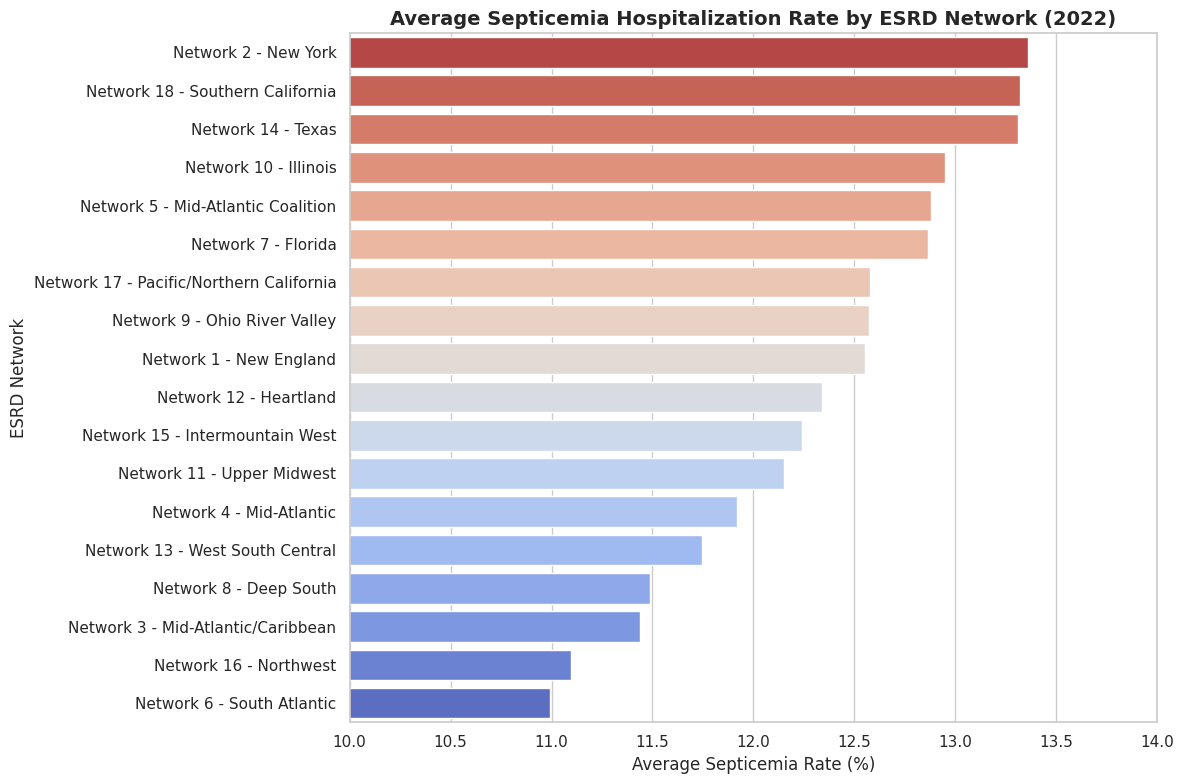

In [ ]:
plt.figure(figsize=(12, 8))

sns.barplot(data=network_avg,
            x='Avg_Septicemia_Rate',
            y='ESRD_Region',
            hue='ESRD_Region',
            palette='coolwarm_r',
            legend=False)

plt.xlim(10, 14)
plt.title('Average Septicemia Hospitalization Rate by ESRD Network (2022)',
          fontsize=14, fontweight='bold')
plt.xlabel('Average Septicemia Rate (%)')
plt.ylabel('ESRD Network')
plt.tight_layout()
plt.show()

## Finding 1: Septicemia Hospitalization Rates Vary by ESRD Network

Average septicemia hospitalization rates across 18 ESRD Networks
ranged from 10.99% (Network 6 - South Atlantic) to 13.36%
(Network 2 - New York) in 2022.

**Highest rates:** New York, Southern California, Texas
**Lowest rates:** South Atlantic, Northwest, Mid-Atlantic/Caribbean

**Key observation:** The 2.37 percentage point spread across all 18
networks suggests relative national consistency in dialysis care
quality, likely reflecting CMS oversight effectiveness. However,
urban-dense networks (New York, Southern California) trend higher,
possibly reflecting patient complexity, socioeconomic factors, or
access challenges rather than facility quality alone.

**Analytical note:** Averages alone don't capture within-network
variation. A follow-up box plot analysis would reveal whether
high-rate networks have uniformly poor performance or are dragged
up by a small number of outlier facilities.

## Clinical Interpretation

Based on six years working with DaVita clinical data, the higher
septicemia rate in Network 2 (New York) and lower rate in Network 6
(South Atlantic) are clinically plausible rather than surprising.

Dense urban networks like New York often serve highly complex dialysis
populations — patients who initiate dialysis urgently, have fragmented
pre-ESRD care, or rely on central venous catheters (CVCs) rather than
more stable arteriovenous fistulas (AVFs). Since catheter access is
strongly associated with bloodstream infection risk, higher CVC
prevalence directly contributes to elevated septicemia rates.

Socioeconomic factors compound this: transportation barriers, housing
instability, missed treatments, and inconsistent vascular access care
all increase infection risk over time.

From a clinical data perspective, this pattern reflects a broader
reality — septicemia rates are not driven by geography alone, but by
the interaction of:
- Patient acuity at dialysis initiation
- Vascular access type (CVC vs AVF)
- Care continuity and treatment adherence
- Facility density and capacity
- Social determinants of health

**Implication for quality improvement:** Interventions targeting CVC
reduction and care continuity in high-rate networks would likely have
greater impact than facility-level quality programs alone.